# Visualising SSH and SSHA along SWOT swaths

In [1]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
from swot_analysis import plotting



In [2]:
#Reading a single file
if False:
    data_dir = '/Users/zoecas/Documents/data/'
    filename = 'SWOT_L2_LR_SSH_Basic_045_216_20260131T225821_20260131T234949_PID0_01.nc'
    
#Reading several swaths files
if True:
    data_dir = Path('/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409')
    files = list(sorted(data_dir.glob('SWOT_L2_LR_SSH_*.nc')))
    print(f'Found {len(list(files))} files')

Found 511 files


In [3]:
#Combining netCDF files in xarray datasets

datasets = [xr.open_dataset(f) for f in files[250:300]] #opening files
datasets = [d.where(np.abs(d.ssha_karin)<2.5) for d in datasets] # Removing abnormal values
_ds = xr.concat(datasets, dim='num_lines') #concatenating along tracks

<GeoAxes: title={'center': 'SSHA [m]'}>

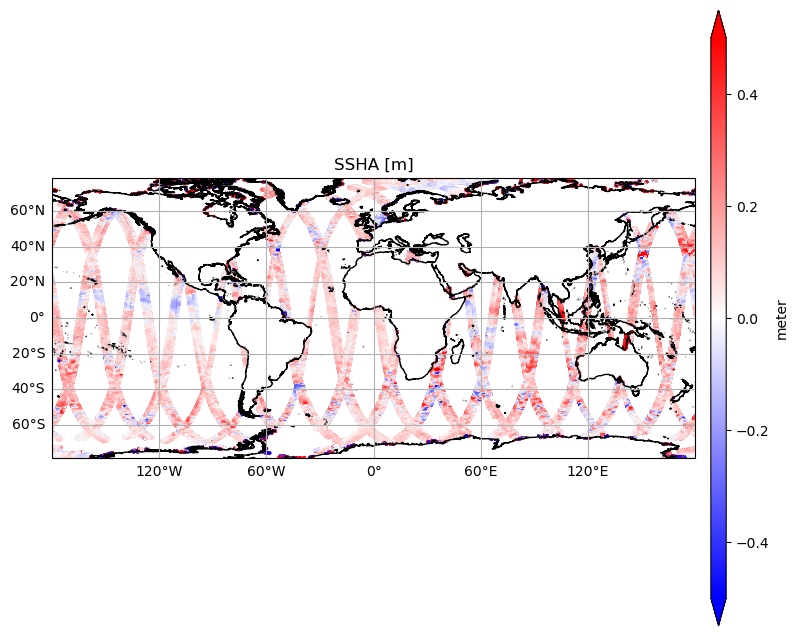

In [4]:

title = 'SSHA [m]'
lon = _ds.longitude.values
lat = _ds.latitude.values
dat = (_ds.ssha_karin+_ds.height_cor_xover).values

vmin, vmax = -0.5,0.5
plotting.plot_segments(lon,lat,dat,title,vmin,vmax)

## Single track analysis


In [5]:
# Tests with 1 file
test = datasets[6]
test

<xarray.Dataset> Size: 128MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines, num_pixels) datetime64[ns] 5MB ...
    time_tai                               (num_lines, num_pixels) datetime64[ns] 5MB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

(-20.0, 34.100217999999984)

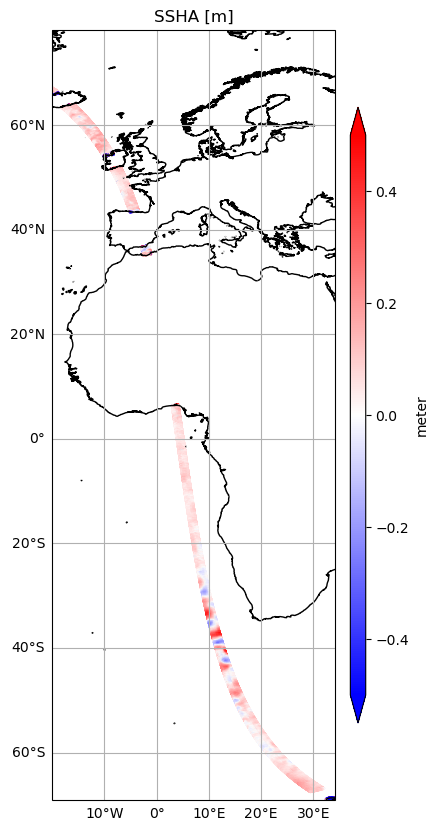

In [6]:
# Whole dataset
title = 'SSHA [m]'
dat = (test.ssha_karin+test.height_cor_xover).where(np.isnan(test.ssha_karin)==False).values
lon = test.longitude.where(np.isnan(dat)==False).values
lat = test.latitude.where(np.isnan(dat)==False).values
vmin, vmax = -0.5,0.5

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plotting.plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,lonmax)

## SWOT LR L2 SSH: KaRIn vs KaRIn 2

The SWOT L2_LR_SSH product provides two KaRIn Sea Surface Height (SSH) estimates:

| Variable | Wet Troposphere Correction |
|-----------|---------------------------|
| `ssh_karin` | Radiometer-based correction |
| `ssh_karin_2` | ECMWF model-based correction |


The two SSH products differ in the source of the wet tropospheric path delay correction applied during processing.

- `ssh_karin` uses the wet troposphere correction derived from the SWOT microwave radiometer.
- `ssh_karin_2` uses a wet troposphere correction derived from ECMWF atmospheric model fields.

### Associated SSHA Variables

Each SSH variable has a corresponding Sea Surface Height Anomaly (SSHA) product. The anomaly products inherit the same wet troposphere correction choice as their parent SSH variables.

### Why Are Two Products Provided?

Wet tropospheric path delay is one of the largest geophysical corrections applied to radar altimetry measurements.

Radiometer retrievals can be degraded by:

- Rain
- Sea ice
- Coastal contamination
- Instrument noise

To provide an alternative estimate, SWOT also distributes products based on ECMWF atmospheric model corrections.

### Impact on SSH and SSHA Spectra

Differences between the two products are generally dominated by the wet troposphere correction.

For spectral analyses, comparing both products can be useful for quantifying the impact of wet tropospheric correction uncertainty on SSH variance and wavelength-dependent signal content.

### Summary

#### `ssh_karin`

**Advantages**
- Uses an observation-based wet troposphere correction.
- Represents the nominal SWOT SSH product.

**Potential Limitations**
- Radiometer retrievals may become noisy or unavailable in challenging observing conditions.

#### `ssh_karin_2`

**Advantages**
- Provides an independent SSH estimate.
- Often exhibits more spatial continuity when radiometer retrievals are degraded.

**Potential Limitations**
- Depends on a numerical weather model rather than direct observations.

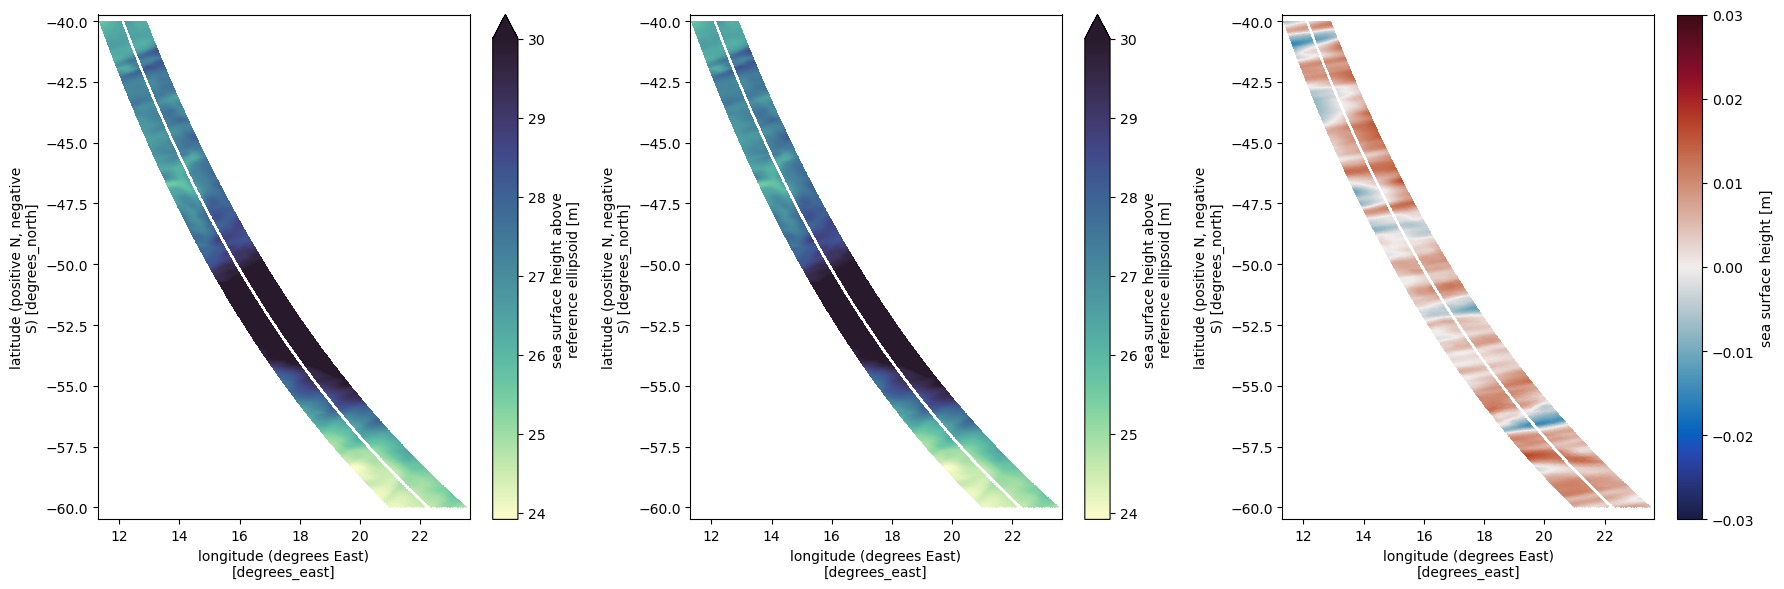

In [26]:
# Zooming in SSHA close to the Alghulas current

ds_sub = test.where((test.latitude>-60)&(test.latitude<-40)
                    &(test.longitude<25)&(test.longitude>10),drop=True)

fig,axs = plt.subplots(1,3,figsize=(18,6))
(ds_sub.ssh_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=30,cmap=cm.cm.deep)
(ds_sub.ssh_karin_2+ds_sub.height_cor_xover).plot(ax=axs[1],x='longitude',y='latitude',vmax=30,cmap=cm.cm.deep)
(ds_sub.ssh_karin_2-ds_sub.ssh_karin).plot(ax=axs[2],x='longitude',y='latitude',vmax=0.03,cmap=cm.cm.balance)
fig.tight_layout()

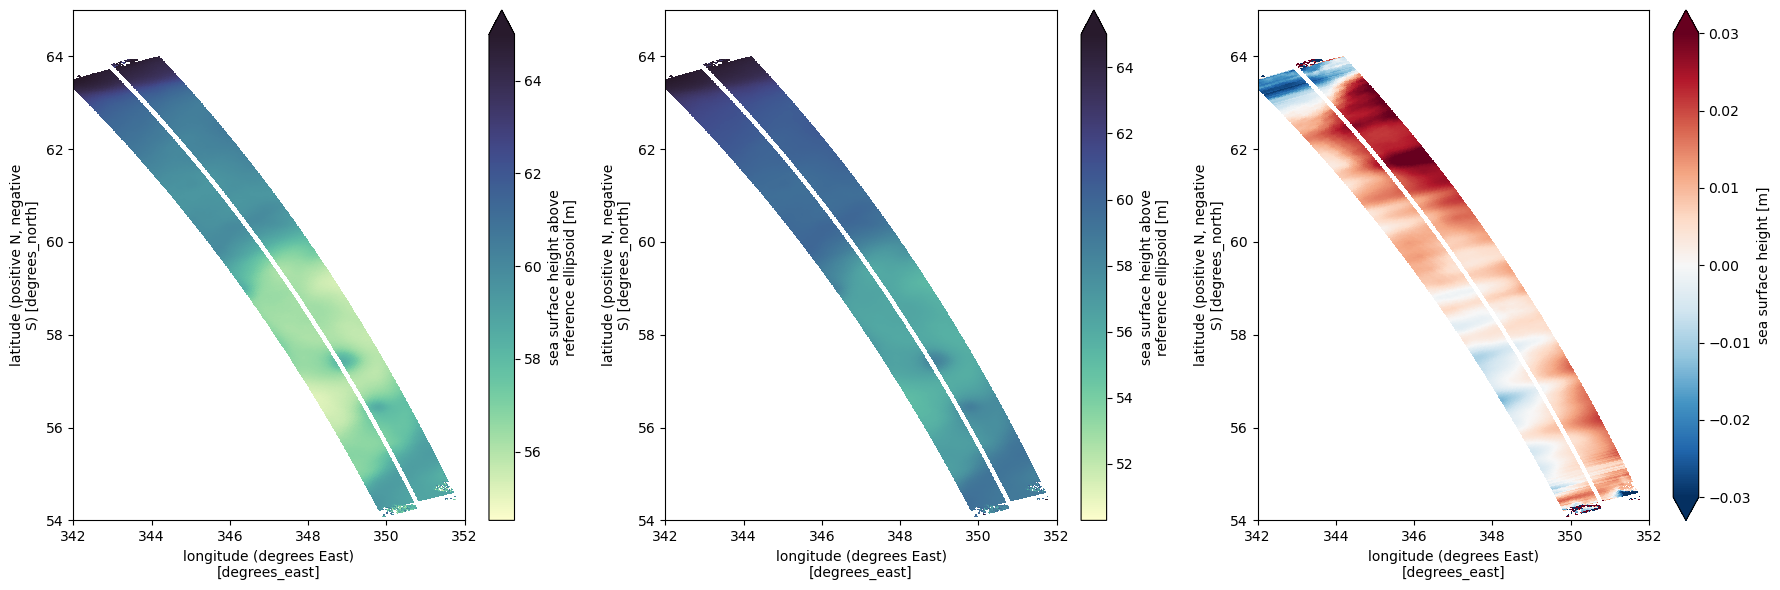

In [27]:
# Zooming south of Iceland

ds_sub = test.where((test.latitude>50)&(test.latitude<65)
                    &(test.longitude<360)&(test.longitude>340),drop=True)

fig,axs = plt.subplots(1,3,figsize=(18,6))
(ds_sub.ssh_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=65,cmap=cm.cm.deep)
(ds_sub.ssh_karin_2+ds_sub.height_cor_xover).plot(ax=axs[1],x='longitude',y='latitude',vmax=65,cmap=cm.cm.deep)
(ds_sub.ssh_karin_2-ds_sub.ssh_karin).plot(ax=axs[2],x='longitude',y='latitude',vmax=0.03);
for ax in axs:
    ax.set_ylim(54,65);ax.set_xlim(342,352)
fig.tight_layout()

## SWOT LR L2 BASIC: SSH to SSHA

The SWOT LR L2 BASIC product provides both **Sea Surface Height (SSH)** and **Sea Surface Height Anomaly (SSHA)** estimates derived from KaRIn measurements.


### Removing Mean Sea Surface

ssha_karin is obtained by removing the mean sea surface (MSS) from ssh_karin:

- ssh_karin contains both the large-scale mean ocean topography and the time-varying ocean signal.
- ssha_karin contains only the time-varying component relative to the MSS.

The MSS includes:

- Geoid-related large-scale structure
- Mean dynamic topography
- Persistent ocean circulation features
- Long-term average sea surface shape

### Treatment of Tides in `ssh_karin` and `ssha_karin`

The difference between `ssh_karin` and `ssha_karin` is not limited to removal of the MSS.

`ssha_karin` is derived from `ssh_karin` after removing several large-scale geophysical signals, including tides and atmospheric effects.

The tidal corrections include:

- Ocean tide
- Load tide
- Equilibrium long-period tide
- Pole tide
- Solid Earth tide
- Coherent internal tide (HRET)

### Practical Consequences

`ssh_karin` is closer to an absolute sea surface height measurement referenced to the ellipsoid.

`ssha_karin` is intended for oceanographic analyses and represents the sea surface height anomaly after removing the dominant deterministic signals from tides, atmospheric forcing, and the mean ocean surface.

For mesoscale and submesoscale studies, crossover analyses, and SSH wavenumber spectra, `ssha_karin` is generally the preferred variable because these large-scale signals have already been removed.

### Impact on Spectral analysis

For SSH wavenumber spectra:

#### Long Wavelengths

At wavelengths of hundreds to thousands of kilometers:

- `ssh_karin` contains substantial energy from the MSS.
- `ssha_karin` generally has reduced variance because the mean ocean structure has been removed.

#### Mesoscale and Smaller Scales

At wavelengths typically associated with mesoscale and submesoscale variability:

- Spectra from `ssh_karin` and `ssha_karin` are often very similar.
- Differences become small relative to the ocean variability signal.

### Conclusions

For most SWOT ocean dynamics applications:

- Use **`ssha_karin`** for spectral analyses, mesoscale studies, crossover statistics, and comparisons with conventional altimetry products.
- Use **`ssh_karin`** when absolute sea surface height is required or when evaluating MSS/geoid-related signals.
- When computing wavenumber spectra, comparing both products can help quantify the contribution of the mean sea surface at long wavelengths.

### Note on HRET

The removal of internal tides using HRET should be taken with caution, especially when studying mesoscale and submesoscale variability.

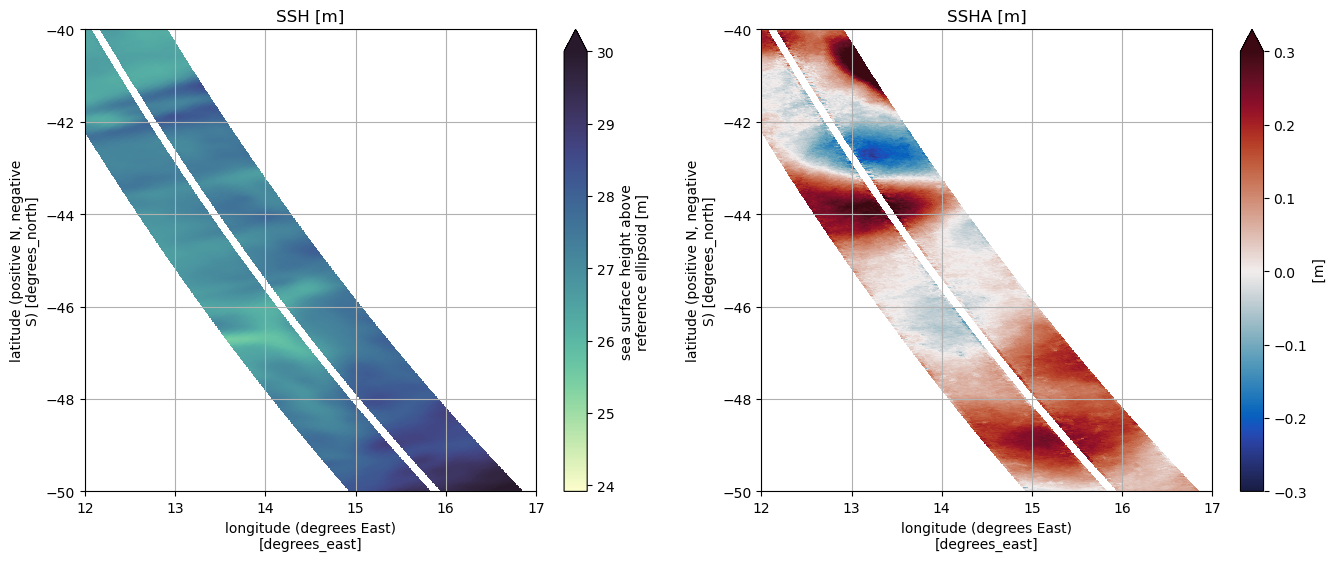

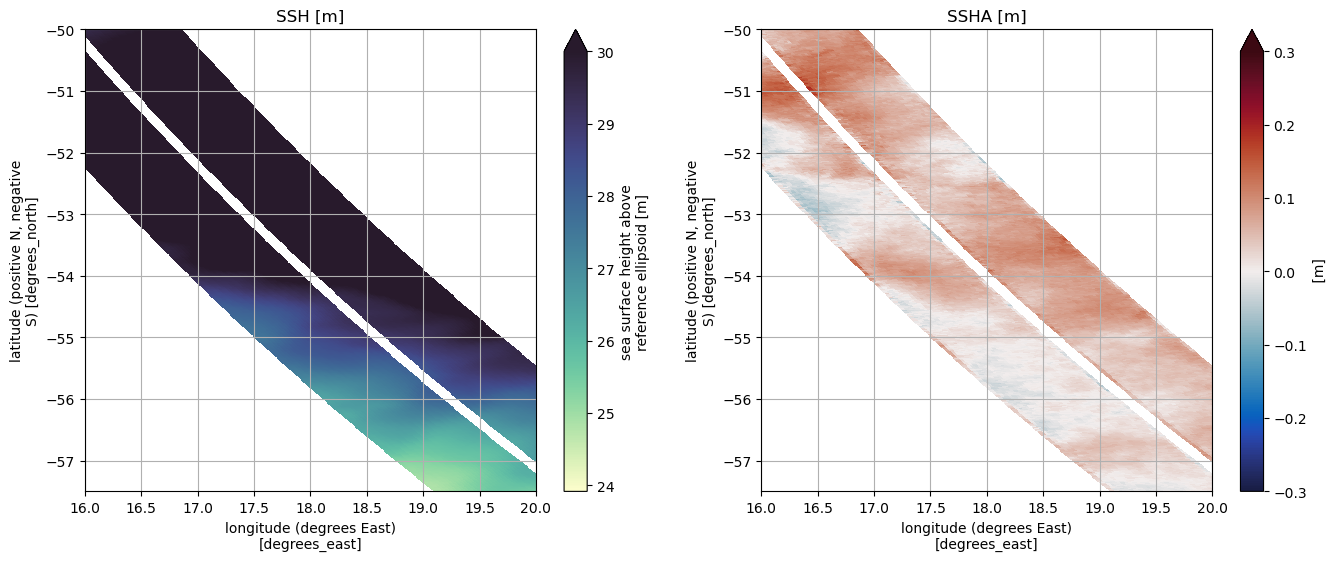

In [32]:
ds_sub = test.where((test.latitude>-60)&(test.latitude<-40)
                    &(test.longitude<25)&(test.longitude>10),drop=True)

fig,axs = plt.subplots(1,2,figsize=(16,6))
(ds_sub.ssh_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=30,cmap=cm.cm.deep)
(ds_sub.ssha_karin+ds_sub.height_cor_xover).plot(ax=axs[1],x='longitude',y='latitude',vmax=0.3,cmap=cm.cm.balance)
axs[0].set_title("SSH [m]");axs[1].set_title("SSHA [m]");
for ax in axs:
    ax.grid();
    ax.set_ylim(-50,-40);ax.set_xlim(12,17);

fig,axs = plt.subplots(1,2,figsize=(16,6))
(ds_sub.ssh_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=30,cmap=cm.cm.deep)
(ds_sub.ssha_karin+ds_sub.height_cor_xover).plot(ax=axs[1],x='longitude',y='latitude',vmax=0.3,cmap=cm.cm.balance)
axs[0].set_title("SSH [m]");axs[1].set_title("SSHA [m]");
for ax in axs:
    ax.grid();
    ax.set_ylim(-57.5,-50);ax.set_xlim(16,20);


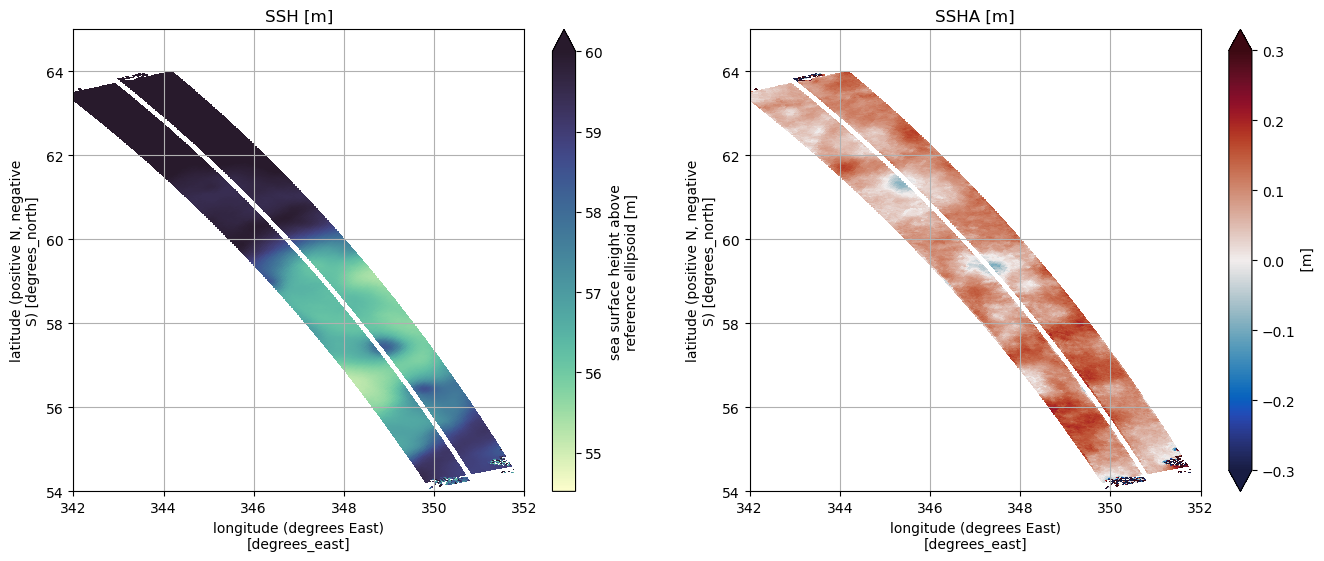

In [34]:
ds_sub = test.where((test.latitude>50)&(test.latitude<65)
                    &(test.longitude<360)&(test.longitude>340),drop=True)

fig,axs = plt.subplots(1,2,figsize=(16,6))
(ds_sub.ssh_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=60,cmap=cm.cm.deep)
(ds_sub.ssha_karin+ds_sub.height_cor_xover).plot(ax=axs[1],x='longitude',y='latitude',vmax=0.3,cmap=cm.cm.balance)
axs[0].set_title("SSH [m]");axs[1].set_title("SSHA [m]");
for ax in axs:
    ax.grid();
    ax.set_ylim(54,65);ax.set_xlim(342,352)


In [37]:
## SWOT LR L2 BASIC SSH to SSHA: focus on HRET internal tides

In [39]:
ds_sub = test.where((test.latitude>-60)&(test.latitude<-40)
                    &(test.longitude<25)&(test.longitude>10),drop=True)

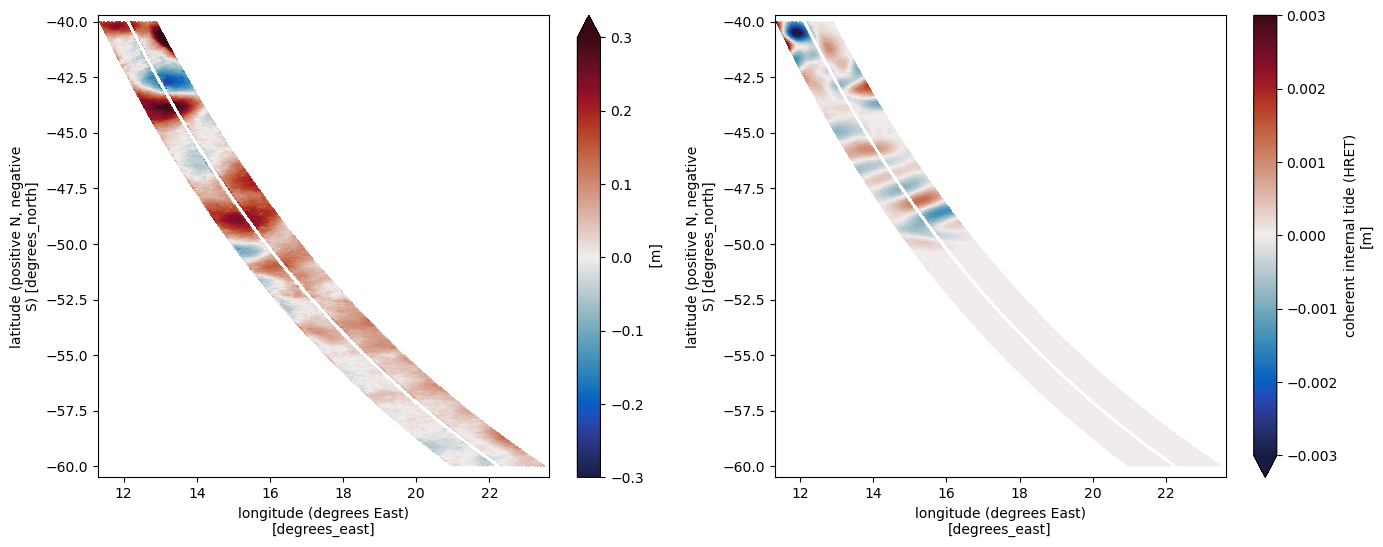

In [48]:
fig,axs = plt.subplots(1,2,figsize=(16,6))
(ds_sub.ssha_karin+ds_sub.height_cor_xover).plot(ax=axs[0],x='longitude',y='latitude',vmax=0.3,cmap=cm.cm.balance)
(ds_sub.internal_tide_hret).plot(ax=axs[1],x='longitude',y='latitude',vmax=0.003,cmap=cm.cm.balance)